<a href="https://colab.research.google.com/github/oluaptom-dev/DBN/blob/main/ND_NOMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teste usando NOMA do arquivo em matlab enviado pelo professor em 06/03/2026


Com base nas fontes, o tema tratado é o ND-NOMA (Noise-Domain Non-Orthogonal Multiple Access), uma técnica que permite que vários usuários compartilhem o mesmo canal de comunicação ao mesmo tempo, usando as propriedades estatísticas do ruído,.
Exemplos para uma pessoa de 16 anos
Para entender o NOMA no "domínio do ruído", imagine que o canal de comunicação é como uma sala onde várias pessoas precisam conversar ao mesmo tempo:
O Exemplo do Tom vs. Volume: Imagine dois amigos falando simultaneamente. Para que você entenda os dois, um deles fala sempre em um tom muito grave ou muito agudo (isso é a média do som), enquanto o outro amigo fala sempre no mesmo tom, mas alternando entre sussurros e gritos (isso é a variância ou "agitação" do som). Você consegue separar as duas mensagens porque elas usam "dimensões" diferentes da voz,.
O Exemplo da Lanterna na Névoa: Imagine dois sinais de luz em uma noite com neblina. Um sinal é uma lanterna que sobe e desce (muda a posição média), e o outro sinal é uma lanterna que fica parada, mas brilha de forma constante ou pisca freneticamente (muda a variância). Mesmo ocupando o mesmo espaço, o observador consegue distinguir o movimento da posição do brilho da intensidade da piscada,.
O Exemplo da Estrada Compartilhada: No rádio comum, cada carro tem sua própria faixa (frequência). No NOMA, os carros compartilham a mesma faixa, mas um viaja sempre pelo lado esquerdo ou direito da pista (média), enquanto o outro viaja exatamente no centro, mas fazendo "zigue-zague" mais largo ou mais estreito (variância),.

O ND-NOMA é uma evolução das comunicações baseadas em ruído para redes de próxima geração (6G) e Internet das Coisas (IoT),.


Conceito Principal: Diferente dos sistemas tradicionais onde cada usuário tem seu próprio tempo ou frequência, o ND-NOMA permite que múltiplos usuários compartilhem os mesmos recursos de tempo e frequência simultaneamente,.

Funcionamento (Uplink/Downlink):
Um usuário (U1) codifica seus bits alterando a média (m) de um sinal ruidoso (ex: média alta para bit 1, média zero para bit 0),.
Um segundo usuário (U2) mantém a média em zero, mas altera a variância (σ2 ), ou seja, a potência da "bagunça" do ruído para representar seus bits,.
A Estação Base recebe a sobreposição desses sinais e consegue separar as mensagens estimando primeiro a média e depois a variância,.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Parâmetros
# ================================
numSymbols = int(1e4)   # número de símbolos
N = 100                 # amostras por símbolo

m = 1                   # média usuário 1
sigmaB = 0.5            # desvio padrão (OODN usuário 2) quando ele transmite bit = 1
                        # U2: bit 0 usa s2 = 0  / bit 1 usa s2 = sigmaB * np.random.randn(N)
                        # s2 = sigmaB*N(0,1) logo Var(s2) = sigmaB^2
sigmaW = 0.1            # desvio padrão AWGN  (do ruído do canal)
                        # pouco ruído para ver o mecanismo funcionando claramente: usuário 1 → detecção por média e usuário 2 → detecção por variância (OODN).
                        # SE sigmaW for grande : ruido compete com s2/piora a detecção do usuario 2./limiar thr2 aumenta também

# Limiar usuário 1 (média)
thr1 = 0

# Limiar usuário 2 (variância)
thr2 = (sigmaB**2)/2 + sigmaW**2  # limiar thr2 é a media da Var ( quando bit = 0 e 1). bit 0 = Var( so ruido AWGN) = Var = sigma2w. bit 1 : Var( sinal + ruido) = Var( sigma2B + sigma2w)
                                  # media é essa formula. (soma e divide por 2)

# ================================
# Geração de bits
# ================================
bits1 = np.random.randint(0, 2, numSymbols)
bits2 = np.random.randint(0, 2, numSymbols)

# Contadores de erro
err1 = 0
err2 = 0

# ================================
# Simulação
# ================================
for k in range(numSymbols):

    # Usuário 1: +m / -m      #sinal deterministico s1∈{+m,−m} / Se bit =1 --> media ~ (+m)  / Se bit = 0 --> media ~ (-m) por isso que limiar ZERO é bom / informação de 1 ordem = media /
    if bits1[k] == 1:
        s1 = m * np.ones(N)
    else:
        s1 = -m * np.ones(N)

    # Usuário 2: OODN        #sinal aleatorio / E[s2 quando bit=1] = zero/ Var(s2 quando bit=1) = sigmaB*sigmaB / randn(N) = N(0,1) / bit = 0 --> silencio / bit = 1 --> ruido isso é OODN /
    if bits2[k] == 1:
        s2 = sigmaB * np.random.randn(N)
    else:
        s2 = np.zeros(N)

    # Canal AWGN
    w = sigmaW * np.random.randn(N)

    y = s1 + s2 + w

    # ============================
    # Decodação usuário 1 (média)
    # ============================
    y_bar = np.mean(y)
    est1 = int(y_bar >= thr1)        # pela media é maior que  o limiar media=0? Se sim é 1 se nao é 0

    # ============================
    # Resíduo para usuário 2
    # ============================
    y_res = y - np.mean(s1)        # assumo aqui que conheco o sinal s1 (que nem sempre é possivel)
    y_res = y - (2*est1 - 1)*m     # uso a estimativa do U1 para descobrir o U2  - Erro propaga para U2  /SIC realista com erro
                                   # SIC basicamente é "Decodificar um sinal primeiro, remover ele do sinal recebido, e depois decodificar o próximo"
                                   # SIC é simples computacionalmente diferente dos SIC convencionais.

    # ============================
    # Decodação usuário 2 (variância)
    # ============================
    var_est = np.var(y_res)   # normalizado por N (igual ao var(...,1))     # y=s1+s2+w com (s1 → usuário 1 (±m, determinístico)/ s2 → usuário 2 (ruído OODN)/w → AWGN)
    est2 = int(var_est >= thr2)

    # ============================
    # Contagem de erros
    # ============================
    err1 += (est1 != bits1[k])
    err2 += (est2 != bits2[k])

# ================================
# BER
# ================================
BER1 = err1 / numSymbols
BER2 = err2 / numSymbols

print(f"BER Usuário 1 (média +m/-m):     {BER1:.3e}")
print(f"BER Usuário 2 (OODN variância): {BER2:.3e}")

# Valor espeado pois o N esta grande
# Valor esperado de U1 para um simbolo é m (vezes 1 vezes N) como m=1 media maior que do U2 (media = 0)
#

BER Usuário 1 (média +m/-m):     0.000e+00
BER Usuário 2 (OODN variância): 0.000e+00


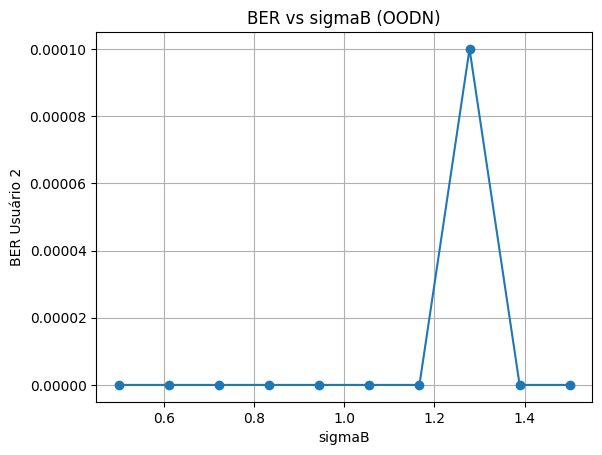

'\nA medida que a variancia de U2 varia (que é sua potencia) tem se: \n   1) Na celula anterio sigmaB = 0,5 com media = 0 para usuario U2\n      para o U1 tem-se media igual a m (para cada simbolo).\n      O ruido do canal é baixo com sigmaW = 0.1  \n\n  2) Se sigmaB aumentar (é desvio padrao o sigma) tem uma potencia sendo aumentada\n     isso vai começar a gerar mais erros, para os demais parametros inalterados.\n'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Parâmetros fixos
# ================================
numSymbols = int(1e4)
N = 100

m = 1
sigmaW = 0.1
thr1 = 0

# ================================
# Variação de sigmaB
# ================================
sigmaB_vals = np.linspace(0.5, 1.5, 10)  # eixo x
BER2_vals = []

# ================================
# Loop sobre sigmaB
# ================================
for sigmaB in sigmaB_vals:

    thr2 = (sigmaB**2)/2 + sigmaW**2

    bits1 = np.random.randint(0, 2, numSymbols)
    bits2 = np.random.randint(0, 2, numSymbols)

    err2 = 0

    for k in range(numSymbols):

        # Usuário 1
        if bits1[k] == 1:
            s1 = m * np.ones(N)
        else:
            s1 = -m * np.ones(N)

        # Usuário 2
        if bits2[k] == 1:
            s2 = sigmaB * np.random.randn(N)
        else:
            s2 = np.zeros(N)

        # Canal
        w = sigmaW * np.random.randn(N)
        y = s1 + s2 + w

        # Decodificação usuário 1
        y_bar = np.mean(y)
        est1 = int(y_bar >= thr1)

        # SIC
        y_res = y - (2*est1 - 1)*m

        # Usuário 2
        var_est = np.var(y_res)
        est2 = int(var_est >= thr2)

        err2 += (est2 != bits2[k])

    BER2 = err2 / numSymbols
    BER2_vals.append(BER2)

# ================================
# Gráfico
# ================================
plt.figure()
plt.plot(sigmaB_vals, BER2_vals, marker='o')
#plt.semilogy(sigmaB_vals, BER2_vals, marker='o')
plt.xlabel('sigmaB')
plt.ylabel('BER Usuário 2')
plt.title('BER vs sigmaB (OODN)')
plt.grid()
plt.show()

'''
A medida que a variancia de U2 varia (que é sua potencia) tem se:
   1) Na celula anterio sigmaB = 0,5 com media = 0 para usuario U2
      para o U1 tem-se media igual a m (para cada simbolo).
      O ruido do canal é baixo com sigmaW = 0.1

  2) Se sigmaB aumentar (é desvio padrao o sigma) tem uma potencia sendo aumentada
     isso vai começar a gerar mais erros, para os demais parametros inalterados.
'''

In [ ]:
# ==============================  Duas curvas
# 6. Plot
# ==============================
plt.figure(figsize=(10, 6))

plt.semilogy(N_range, ber_theo_awgn, 'ko-', label=f'DBN (sim) AWGN (SNR={snr_db_1})')  # 'cor + marcador + linha (opcional)'
plt.semilogy(N_range, ber_theo_nLos, 'bo-', label=f'DBN (sim) NLoS (SNR={snr_db_1})')  # 'cor + marcador + linha (opcional)'
#plt.semilogy(snr_db_range, ber_sim, 'ro--', label=f'Monte Carlo (N={N})')
#plt.semilogy(snr_db_range, ber_appr, 'mo:', label=f'Aproxi. Gaussiana (N={N})')
plt.semilogy(N_range, BER_sim_OODN, 'yo-', label=f'OODN (sim) AWGN (SNR={snr_db_1})')  #
plt.semilogy(N_range, BER_theo_OODN, 'go-', label=f'OODN (theo) AWGN (SNR={snr_db_1})')  #

#  os^x+*d = circulo/quadrado/triangulo/X/mais/estrela/losango
#  bgrcmyk = azul/verde/vermelho/ciano/magenta/amarelo/preto
#  -/--/-./:   = continua/tracejada/traço-ponto/pontilhada

plt.grid(True, which='both', linestyle='--')
plt.xlabel('N ganho ')
plt.ylabel('BEP')
plt.title(f'Parte da Fig. 3 b) do artigo apenas com o DBN - Desempenho (N = {N})')
plt.legend()
plt.ylim(1e-6, 1) # Define o limite inferior do eixo Y para 10^-5 e o superior para 1
plt.xlim(50, 400) # Define o limite inferior do eixo X para -10 e +10
#plt.xticks(np.arange(-10, 11, 2)) # Define os ticks do eixo X de -10 a +10 com
plt.xticks(np.arange(50, 401, 50))   # de 50 até 400, de 50 em 50

plt.text(0.05, 0.05, 'NLoS', transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='bottom', horizontalalignment='left')

NameError: name 'N_range' is not defined

<Figure size 1000x600 with 0 Axes>